In [1]:
import numpy as np 
import miepython as mie
import pandas as pd 

np.random.seed(42)
n_samples = 3000

#input radius partikel (nm), indeks refraksi material, wavelength (nm)
radius = np.random.uniform(20, 200, n_samples)
diameter = 2 * radius
n_material = np.random.uniform(1.3, 2.5, n_samples)
wavelength = np.random.uniform(400, 800, n_samples)

# size parameter x = 2 * pi * r / lambda
x = 2 * np.pi * radius / wavelength
m = n_material # relative refractive index terhadap medium (medium = udara/vacuum, n=1)

qext, qsca, qback, g = mie.efficiencies(m,  diameter, wavelength)

df = pd.DataFrame({
    "radius_nm": radius,
    "n_material": n_material,
    "wavelength_nm": wavelength, 
    "qsca": qsca,
    "qext": qext
})
df.to_csv("mie_dataset.csv", index=False)

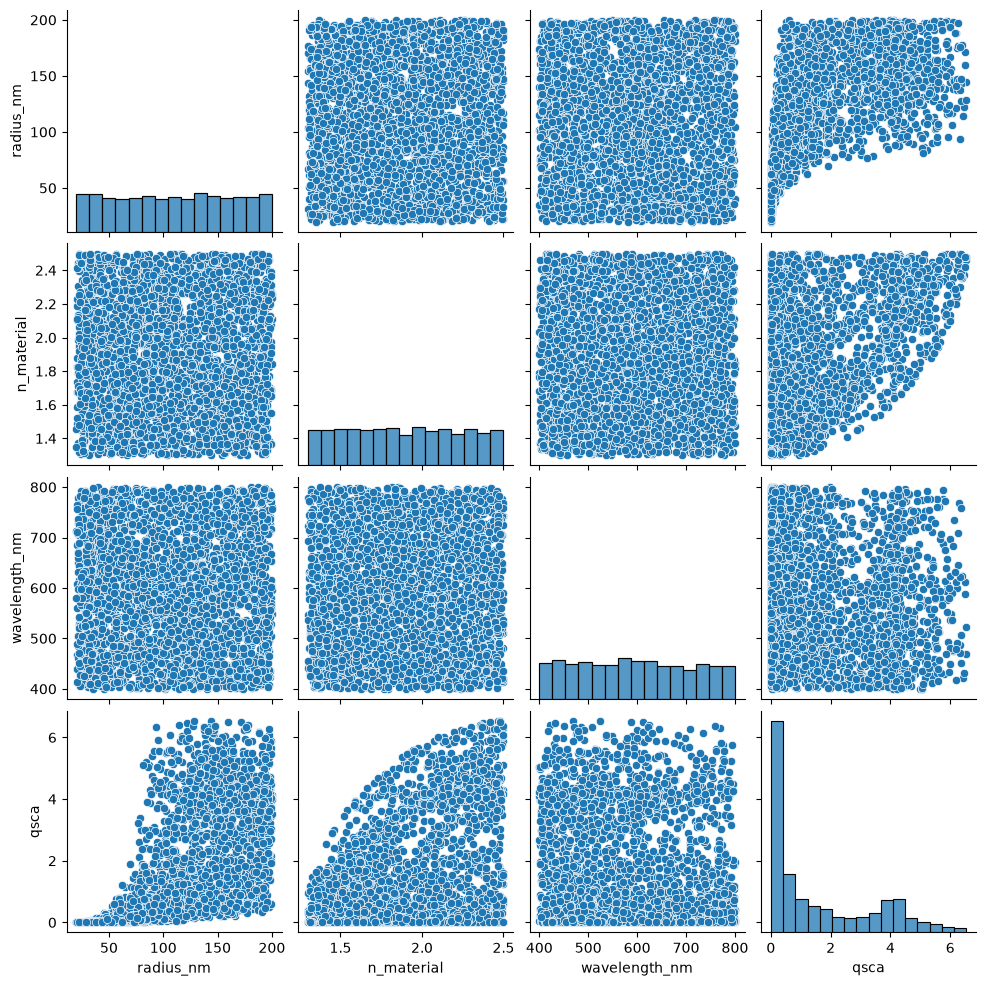

<Axes: >

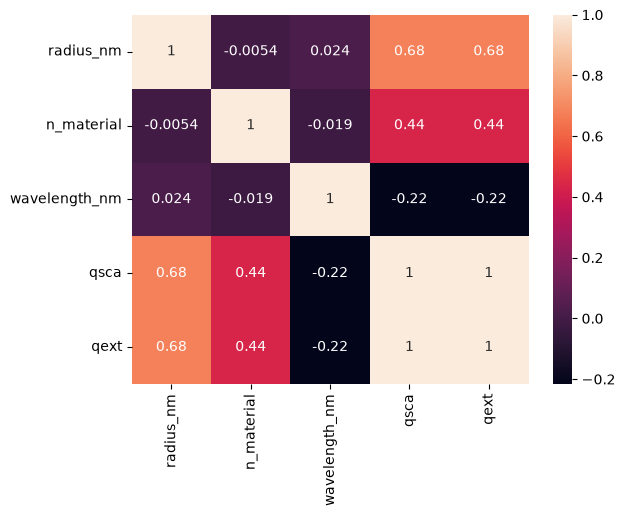

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df.describe()
sns.pairplot(df[["radius_nm", "n_material", "wavelength_nm", "qsca"]])
plt.show()

sns.heatmap(df.corr(), annot=True)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[["radius_nm", "n_material", "wavelength_nm"]]
y = df[["qsca"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# baseline 1: Linear Regression
lr = LinearRegression().fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
print("Linear R²:", r2_score(y_test, pred_lr))

# baseline 2: Random Forest (harusnya lebih bagus karena hubungannya non-linear)
rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)
print("RF R²:", r2_score(y_test, pred_rf))

Linear R²: 0.6961772115351987


c:\Users\90171726\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RF R²: 0.962328023259923


Text(0.5, 1.0, 'Random Forest: Predicted vs Actual')

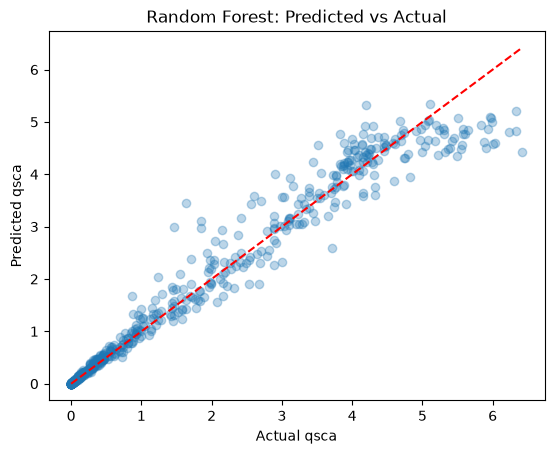

In [5]:
plt.scatter(y_test, pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual qsca")
plt.ylabel("Predicted qsca")
plt.title("Random Forest: Predicted vs Actual")

In [7]:
X_inv = df[["wavelength_nm", "qsca"]]
y_inv = df["radius_nm"]

X_train, X_test, y_train, y_test = train_test_split(X_inv, y_inv, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled_inv = scaler.fit_transform(X_train)
X_test_scaled_inv = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# baseline 1: Linear Regression
lr = LinearRegression().fit(X_train_scaled_inv, y_train)
pred_lr = lr.predict(X_test_scaled_inv)
print("Linear R²:", r2_score(y_test, pred_lr))

# baseline 2: Random Forest (harusnya lebih bagus karena hubungannya non-linear)
rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train_scaled_inv, y_train)
pred_rf = rf.predict(X_test_scaled_inv)
print("RF R²:", r2_score(y_test, pred_rf))

Linear R²: 0.4789991906964818
RF R²: 0.7264275864855309


Text(0.5, 1.0, 'Random Forest: Predicted vs Actual Inverse')

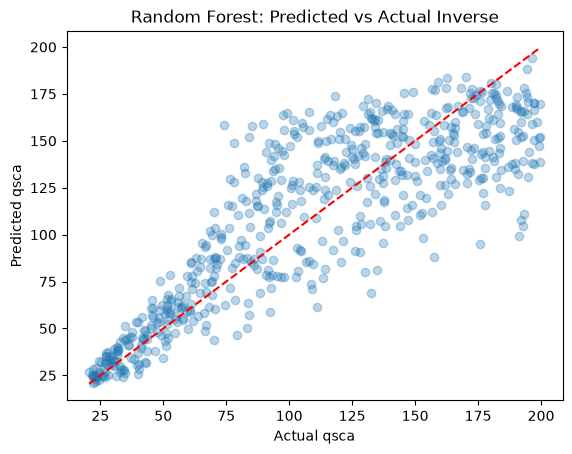

In [9]:
plt.scatter(y_test, pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual qsca")
plt.ylabel("Predicted qsca")
plt.title("Random Forest: Predicted vs Actual Inverse")